<a href="https://colab.research.google.com/github/Jompy-GitHub/MTS-UncertainEnvironment/blob/main/analisis-resultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Configurar el entorno: Pruebas Multiindicio
Ejecutar siempre al principio

In [1]:
# Montar unidad de Drive
from google.colab import drive
import os
import json
import subprocess

drive.mount("/content/drive")
path = "drive/MyDrive/TFG-Yago Broton/Busqueda con incertidumbre/Código/TFG-Yago"
os.chdir(path)
print(os.listdir(os.getcwd()))

Mounted at /content/drive
['.ipynb_checkpoints', 'resultados', 'pruebas', 'graficas', 'graficas-enjambre', 'graficas-indicios', 'lanzar-pruebas.ipynb', 'analisis-resultados-multiagente.ipynb', 'analisis-resultados.ipynb', 'analisis-resultados-multiindicio.ipynb']


In [2]:
# Importar librerías
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

# Para poder exportar las gráficas de plotly a pdf
!pip install -U kaleido
import kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.2 MB/s eta 0:00:00


In [3]:
def process_csv(file_path):
    # Coger el CSV y leer lo que nos interesa para las estadísticas
    # etiquetas, pasos y si se encontró el objetivo
    # Coger las filas: 3 (dist), 4(pasos/tiempo), 4(found),
    df = pd.read_csv(file_path, header=0, index_col=0 , nrows=3, skiprows=[1,2])

    # Sacar la estrategia del nombre del archivo
    strategy = os.path.basename(file_path).split(".")[0].split("-")[:-1]
    strategy = "-".join(strategy)

    # Sacar la información del df
    finder = (df.loc["Found Target", "Target"])
    found = not np.isnan(finder)
    distance = float(df.loc["Distance", "Agent " + str(int(finder))]) if found else df.loc["Distance", "Agent 0"]
    steps = float(df.loc["Steps taken", "Agent 0"])
    steps_f = float(df.loc["Steps taken", "Agent " + str(int(finder))]) if found else None
    agents = len(df.columns) - 1

    result_df = pd.DataFrame(
        {
            "Strategy": strategy,
            "Number of Agents": agents,
            "Steps": steps,
            "Steps finder": steps_f,
            "Distance": distance,
            "Found": found,
        },
        index=(["values"]),
    )
    return result_df

In [4]:
def process_all(directory):
    # Toma todos los archivos csv de la carpeta y los "procesa" (juntar los datos en un df)
    all_data = []
    for filename in os.listdir(directory):
        if not filename.endswith(".csv"):
            continue
        file_path = os.path.join(directory, filename)
        df = process_csv(file_path)
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

In [5]:
# Definir cólores y estilo para cada estrategia
# (en diccionarios para asegurarnos que las asignaciones son connsistentes)
strategies = ["expanding","lawnmower", "ldfs-myop", "ldfs-heur"]

colors_found = {
    "Found": "#5BA48A",
    "Not found": "#A45B75"
}

strategy_colors = {
    "expanding": "#5B75A4",
    "lawnmower": "#A45B99",
    "ldfs-myop": "#A48A5B",
    "ldfs-heur": "#5BA466",
    "failure":   "#BFACB5"
}

strategy_symbols = {  # Aunque no vamos a usar scatterplots
    "expanding": "circle",
    "lawnmower": "square",
    "ldfs-myop": "triangle-up-open",
    "ldfs-heur": "diamond",
    "failure": "x"
}

strategy_lines = {
   "expanding": "solid",
   "lawnmower": "dash",
   "ldfs-myop": "dot",
   "ldfs-heur": "dashdot",
   "failure": "longdash"
}

# Comparar métodos de búsqueda: escenarios multi-indicio
Fuerza bruta: lawnmower y expanding square  
*vs*  
Algorítmos guiados por heurísticas

# Caso de estudio 1: Escenario 1 (pequeño)
- indicios: 2, objetivo variable dentro del indicio fijo
- agentes: 1, posición fija
- escenario: pequeño


**TO DO 🖼️**


## Cargar los archivos

In [6]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "indicios-2-agentes-1"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp1_1 = process_all(testing_path)

successful_df_exp1_1 = combined_data_exp1_1[combined_data_exp1_1["Found"]]

In [7]:
print(combined_data_exp1_1)

       Strategy  Number of Agents  Steps Steps finder  Distance  Found
0     expanding                 1   97.0         97.0   99.4853   True
1     expanding                 1   77.0         77.0   79.4853   True
2     expanding                 1   41.0         41.0   43.4853   True
3     expanding                 1   40.0         40.0   42.4853   True
4     expanding                 1  101.0        101.0  103.4853   True
...         ...               ...    ...          ...       ...    ...
3995  ldfs-heur                 1  200.0         None  203.7279  False
3996  ldfs-heur                 1  200.0         None  203.7279  False
3997  ldfs-heur                 1  200.0         None  203.7279  False
3998  ldfs-heur                 1  200.0         None  203.7279  False
3999  ldfs-heur                 1  200.0         None  203.7279  False

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [8]:
# Descripción general de los datos
combined_data_exp1_1.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,999.0,83.538539,50.238751,3.0,36.0,79.0,143.0,201.0
lawnmower,1000.0,132.945000,22.844909,92.0,116.0,138.0,152.0,175.0
ldfs-heur,1001.0,200.000000,0.000000,200.0,200.0,200.0,200.0,200.0
ldfs-myop,1000.0,65.966000,55.395338,5.0,9.0,116.0,120.0,135.0


In [9]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp1_1.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,81.0
lawnmower,143.0
ldfs-heur,200.0
ldfs-myop,122.0


In [10]:
combined_data_exp1_1.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,999.0,346.0,10.8995,14.0
lawnmower,1000.0,42.0,119.0738,73.0
ldfs-heur,1001,2,203.7279,1000
ldfs-myop,1000.0,23.0,141.0955,106.0


#### Histogramas

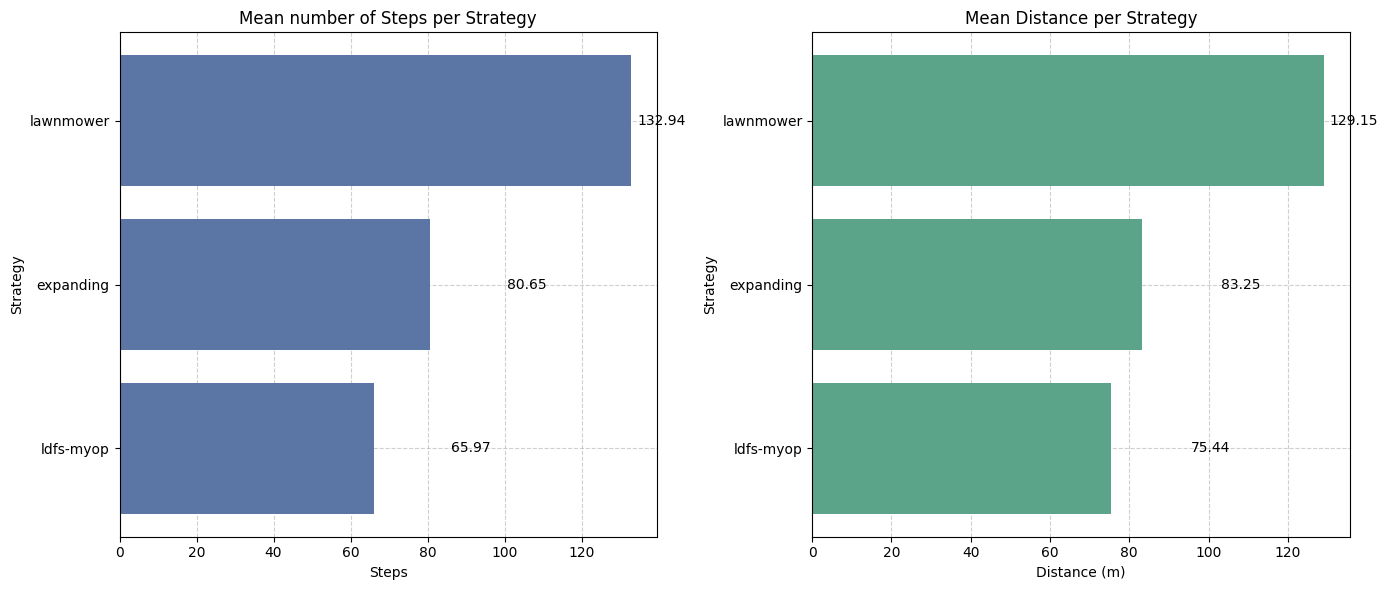

In [11]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp1_1.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp1_1.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
x_max = axes[0].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_steps:
    axes[0].text(min(bar.get_width() + 20, x_max - 5), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
x_max = axes[1].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_distance:
    axes[1].text(min(bar.get_width() + 20, x_max -5), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas-indicios/exp-1-1-peq/histo-pasos-1-1-peq.pdf")
plt.show()

Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [12]:
execution_data = []

for strategy, group in combined_data_exp1_1.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [13]:
global_xmin = combined_data_exp1_1["Steps"].min()
global_xmax = combined_data_exp1_1["Steps"].max()
global_ymax = combined_data_exp1_1.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp1_1[combined_data_exp1_1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas-indicios/exp-1-1-peq/histo-dist-1-1-peq.pdf")
fig_hist.show()

In [14]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_1[combined_data_exp1_1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)


fig_combined.write_image("graficas-indicios/exp-1-1-peq/histo-dist-comb-1-1-peq.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [15]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_1[combined_data_exp1_1['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas-indicios/exp-1-1-peq/cdf-1-1-peq.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [16]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp1_1,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp1_1[combined_data_exp1_1['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas-indicios/exp-1-1-peq/boxplot-1-1-peq.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [17]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp1_1.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)

success_stats

,num_attempts,successes,success_rate
Strategy,,,
expanding,999,975,97.6
lawnmower,1000,1000,100.0
ldfs-heur,1001,0,0.0
ldfs-myop,1000,1000,100.0


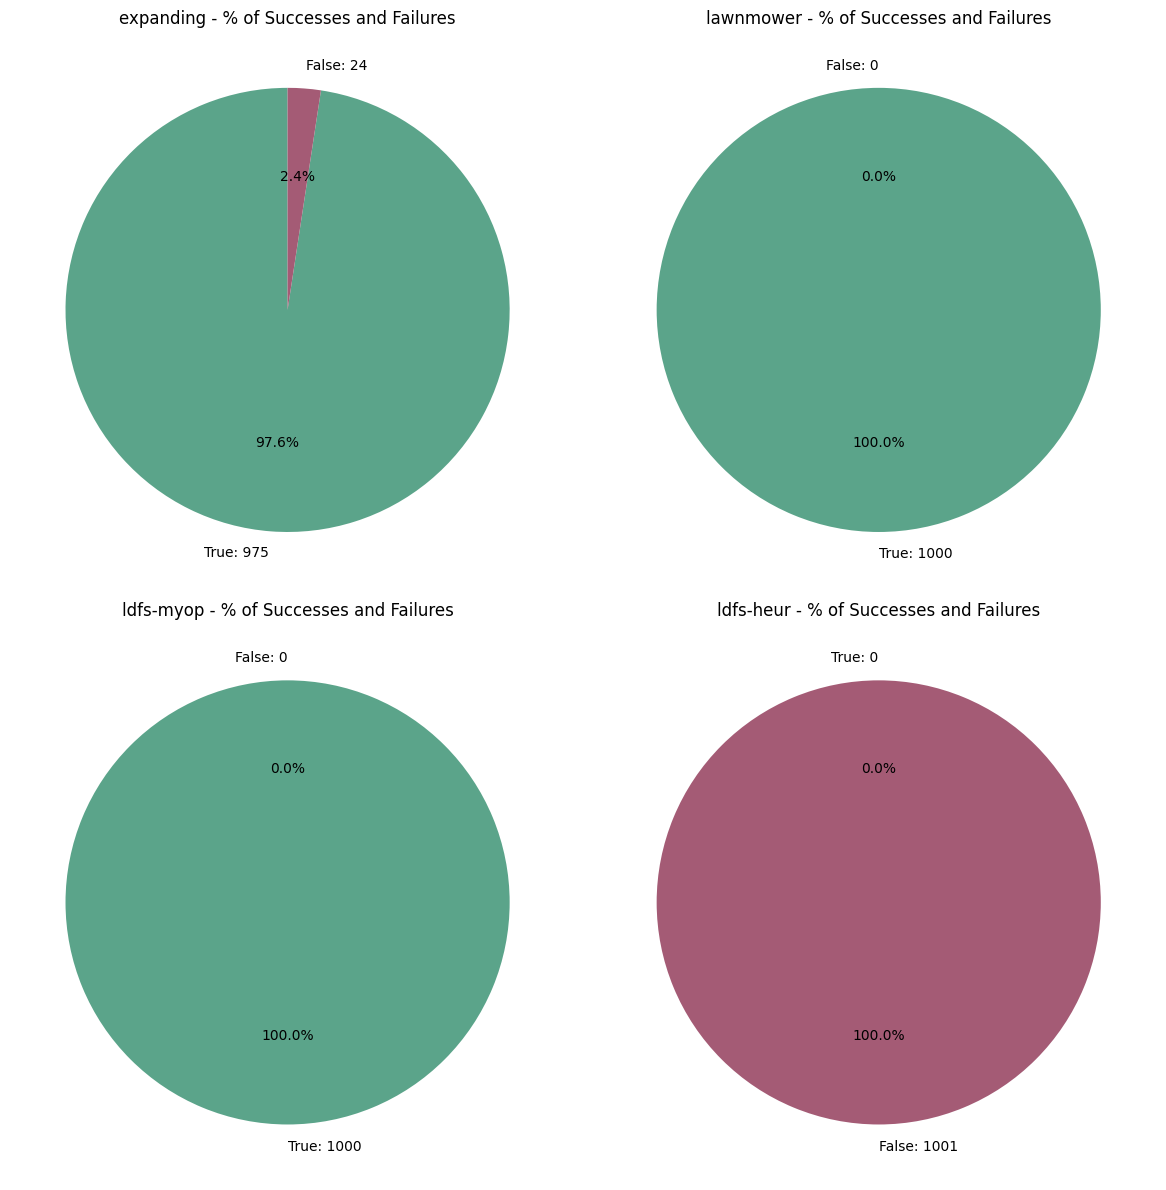

In [18]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(2, 2, figsize=(12,12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp1_1[combined_data_exp1_1["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


# ax_total = axes[len(strategies)]
# found_counts_total = combined_data_exp1_1["Found"].value_counts()
# values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
# labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

# ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
# ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Quitar el el 6 gráfico de la malla
# for j in range(len(strategies), len(axes)):
#     fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas-indicios/exp-1-1-peq/pie-exito-1-1-peq.pdf")
plt.show()

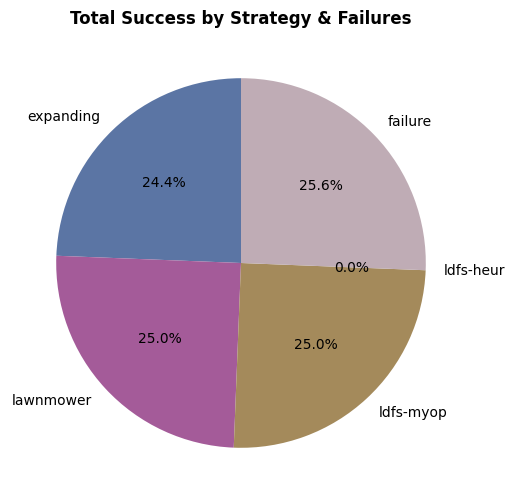

In [19]:
success_counts = combined_data_exp1_1[combined_data_exp1_1["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp1_1["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas-indicios/exp-1-1-peq/pie-exito-total-1-1-peq.pdf")
plt.show()

# Caso de estudio 1: Escenario 2 (mediano)
- indicios: 2, posición fija
- agentes: 1, posición fija
- escenario: pequeño


**TO DO 🖼️**

## Cargar los archivos

In [20]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "mediano-indicios-2-agentes-1"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp1_2 = process_all(testing_path)

successful_df_exp1_2 = combined_data_exp1_2[combined_data_exp1_2["Found"]]

In [21]:
print(combined_data_exp1_2)

       Strategy  Number of Agents  Steps Steps finder  Distance  Found
0     expanding                 1  121.0         None  129.6985  False
1     expanding                 1  121.0         None  128.0416  False
2     expanding                 1  121.0         None  124.7279  False
3     expanding                 1  121.0         None     121.0  False
4     expanding                 1  121.0         None  129.2843  False
...         ...               ...    ...          ...       ...    ...
3995  ldfs-heur                 1  120.0         None  164.3209  False
3996  ldfs-heur                 1  120.0         None  168.0488  False
3997  ldfs-heur                 1  120.0         None  168.8772  False
3998  ldfs-heur                 1  120.0         None  161.8356  False
3999  ldfs-heur                 1   29.0         29.0   41.0122   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [22]:
# Descripción general de los datos
combined_data_exp1_2.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,114.606,26.528485,2.0,121.00,121.0,121.0,121.0
lawnmower,1000.0,91.384,41.556534,1.0,57.75,121.0,121.0,121.0
ldfs-heur,1000.0,105.811,33.568022,1.0,120.00,120.0,120.0,120.0
ldfs-myop,1000.0,89.432,42.662788,1.0,57.00,120.0,120.0,120.0


In [23]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp1_2.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,121.0
lawnmower,121.0
ldfs-heur,120.0
ldfs-myop,120.0


In [24]:
combined_data_exp1_2.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000,35,121.0,69
lawnmower,1000,163,118.7334,438
ldfs-heur,1000,110,168.463,67
ldfs-myop,1000.0,522.0,1.4142,28.0


#### Histogramas

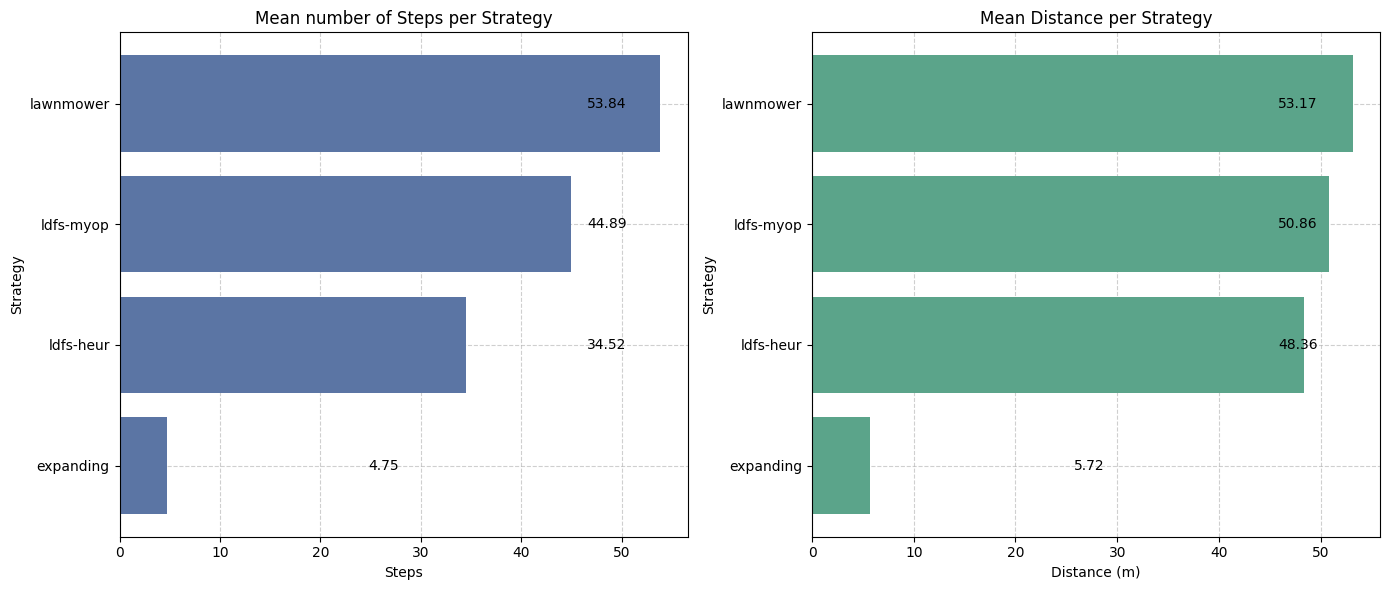

In [25]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp1_2.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp1_2.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
x_max = axes[0].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_steps:
    axes[0].text(min(bar.get_width() + 20, x_max - 10), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
x_max = axes[1].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_distance:
    axes[1].text(min(bar.get_width() + 20, x_max -10), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas-indicios/exp-1-2-mediano/histo-pasos-1-2-mediano.pdf")
plt.show()

Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [26]:
execution_data = []

for strategy, group in combined_data_exp1_2.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [27]:
global_xmin = combined_data_exp1_2["Steps"].min()
global_xmax = combined_data_exp1_2["Steps"].max()
global_ymax = combined_data_exp1_2.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=1,
    cols=4,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = 1
    col = idx +1 # % 2 + 1

    strategy_data = combined_data_exp1_2[combined_data_exp1_2['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=500,
    width=2000,
    bargap=0.1,
)

fig_hist.write_image("graficas-indicios/exp-1-2-mediano/histo-dist-1-2-mediano.pdf")
fig_hist.show()

In [28]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_2[combined_data_exp1_2['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas-indicios/exp-1-2-mediano/histo-dist-comb-1-2-mediano.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [29]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_2[combined_data_exp1_2['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas-indicios/exp-1-2-mediano/cdf-1-2-mediano.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [30]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp1_2,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp1_2[combined_data_exp1_2['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas-indicios/exp-1-2-mediano/boxplot-1-2-mediano.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [31]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp1_2.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
success_stats

,num_attempts,successes,success_rate
Strategy,,,
expanding,1000,55,5.5
lawnmower,1000,441,44.1
ldfs-heur,1000,166,16.6
ldfs-myop,1000,407,40.7


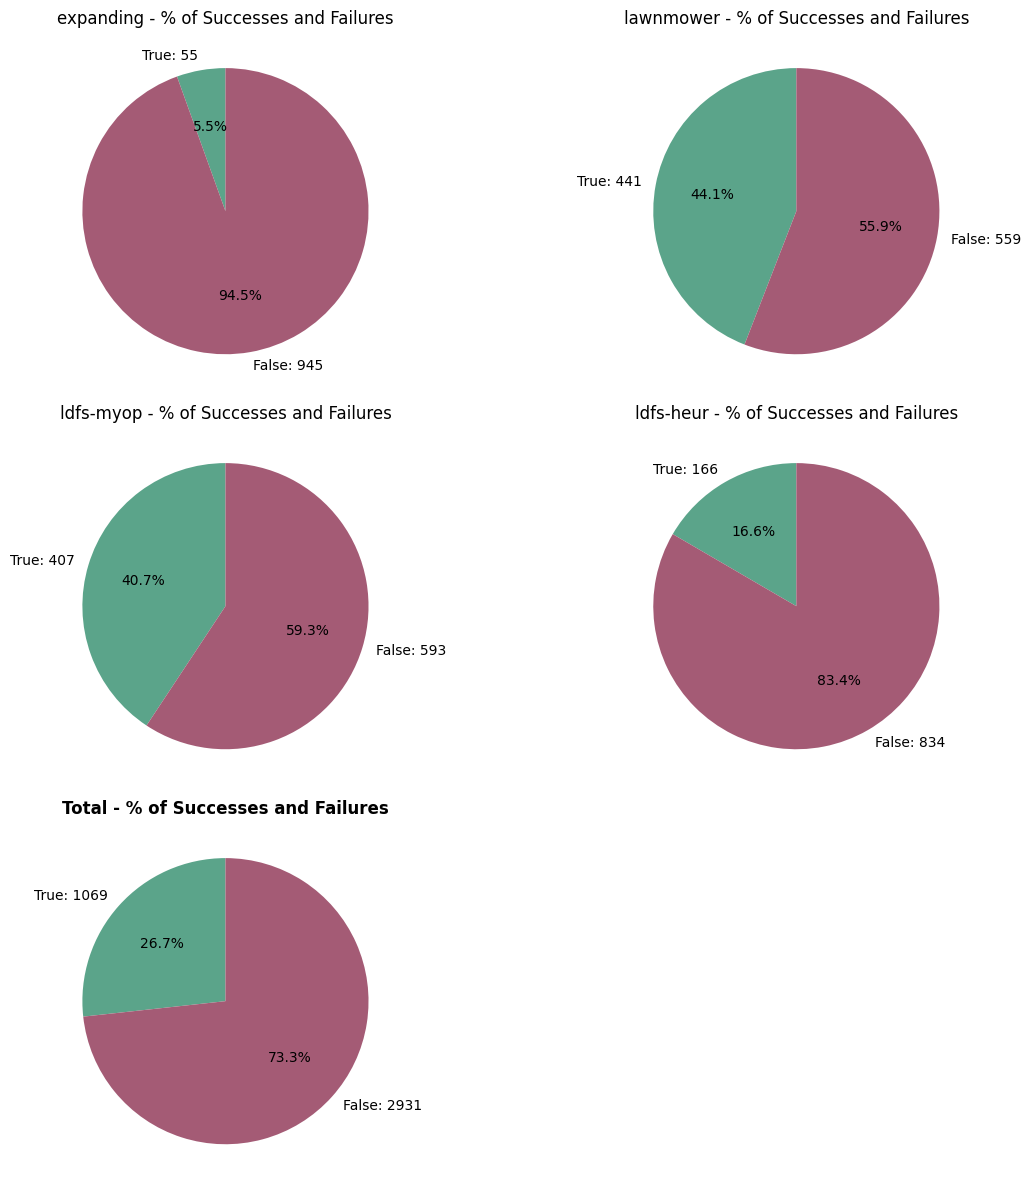

In [32]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp1_2[combined_data_exp1_2["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp1_2["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas-indicios/exp-1-2-mediano/pie-exito-1-2-mediano.pdf")
plt.show()

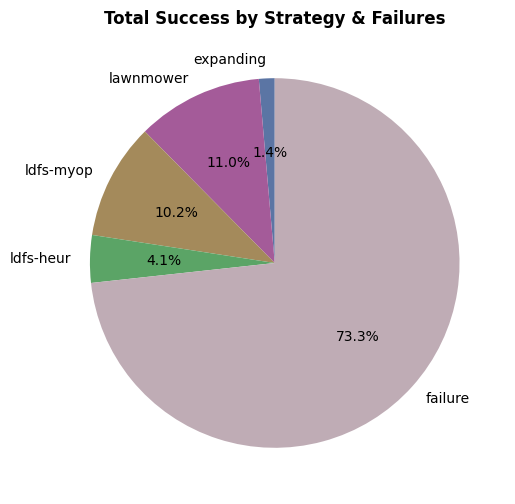

In [33]:
success_counts = combined_data_exp1_2[combined_data_exp1_2["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp1_2["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas-indicios/exp-1-2-mediano/pie-exito-total-1-2-mediano.pdf")
plt.show()

# Caso de estudio 1: Escenario 3
- indicios: 2, posición fija
- agentes: 1, posición variable
- escenario: grande


**TO DO 🖼️**

## Cargar los archivos

In [34]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "grande-indicios-2-agentes-1"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp1_3 = process_all(testing_path)

successful_df_exp1_3 = combined_data_exp1_3[combined_data_exp1_3["Found"]]

In [35]:
print(combined_data_exp1_3)

       Strategy  Number of Agents   Steps Steps finder   Distance  Found
0     lawnmower                 1   737.0        737.0   729.7334   True
1     lawnmower                 1   765.0        765.0   757.7334   True
2     lawnmower                 1  1201.0         None  1189.7334  False
3     lawnmower                 1  1201.0         None  1188.7334  False
4     lawnmower                 1  1201.0         None  1188.7334  False
...         ...               ...     ...          ...        ...    ...
3995  ldfs-heur                 1  1200.0         None  1277.5626  False
3996  ldfs-heur                 1   861.0        861.0   935.6438   True
3997  ldfs-heur                 1   402.0        402.0   444.7716   True
3998  ldfs-heur                 1   179.0        179.0   200.7229   True
3999  ldfs-heur                 1   328.0        328.0   356.8894   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [36]:
# Descripción general de los datos
combined_data_exp1_3.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,1173.871,176.904787,17.0,1201.00,1201.0,1201.0,1201.0
lawnmower,1000.0,981.358,225.631264,714.0,751.00,1201.0,1201.0,1201.0
ldfs-heur,1000.0,716.700,501.222705,1.0,126.50,881.0,1200.0,1200.0
ldfs-myop,1000.0,930.797,451.669693,1.0,683.25,1200.0,1200.0,1200.0


In [37]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp1_3.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,1201.0
lawnmower,1201.0
ldfs-heur,1200.0
ldfs-myop,1200.0


In [38]:
combined_data_exp1_3.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000,55,1208.8701,30
lawnmower,1000,99,1188.7334,288
ldfs-heur,1000.0,923.0,22.6274,3.0
ldfs-myop,1000,905,1314.2022,3


#### Histogramas

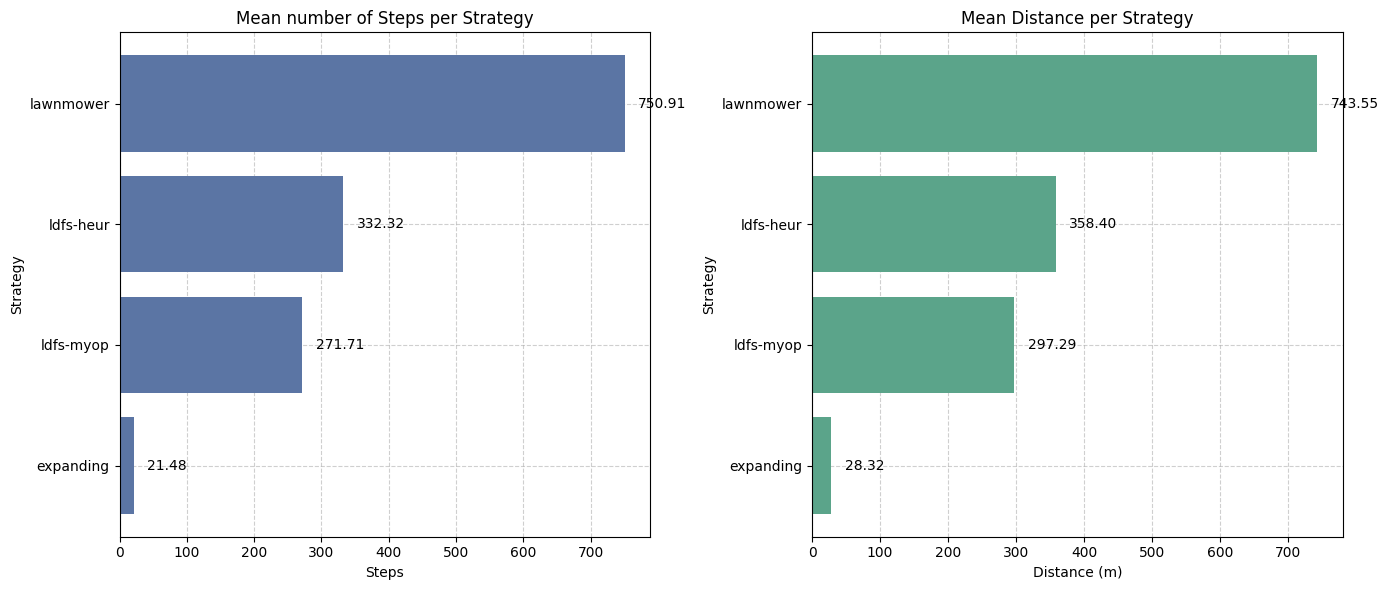

In [39]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp1_3.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp1_3.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
x_max = axes[0].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_steps:
    axes[0].text(min(bar.get_width() + 20, x_max -10), bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
x_max = axes[1].get_xlim()[1]  # Máximo valor del eje X
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas-indicios/exp-1-3-grande/histo-pasos-1-3-grande.pdf")
plt.show()

Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [40]:
execution_data = []

for strategy, group in combined_data_exp1_3.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [41]:
global_xmin = combined_data_exp1_3["Steps"].min()
global_xmax = combined_data_exp1_3["Steps"].max()
global_ymax = combined_data_exp1_3.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp1_3[combined_data_exp1_3['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas-indicios/exp-1-3-grande/histo-dist-1-3-grande.pdf")
fig_hist.show()

In [42]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_3[combined_data_exp1_3['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas-indicios/exp-1-3-grande/histo-dist-comb-1-3-grande.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [43]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp1_3[combined_data_exp1_3['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas-indicios/exp-1-3-grande/cdf-1-3-grande.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [44]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp1_3,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp1_3[combined_data_exp1_3['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas-indicios/exp-1-3-grande/boxplot-1-3-grande.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [45]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp1_3.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
success_stats

,num_attempts,successes,success_rate
Strategy,,,
expanding,1000,23,2.3
lawnmower,1000,488,48.8
ldfs-heur,1000,557,55.7
ldfs-myop,1000,290,29.0


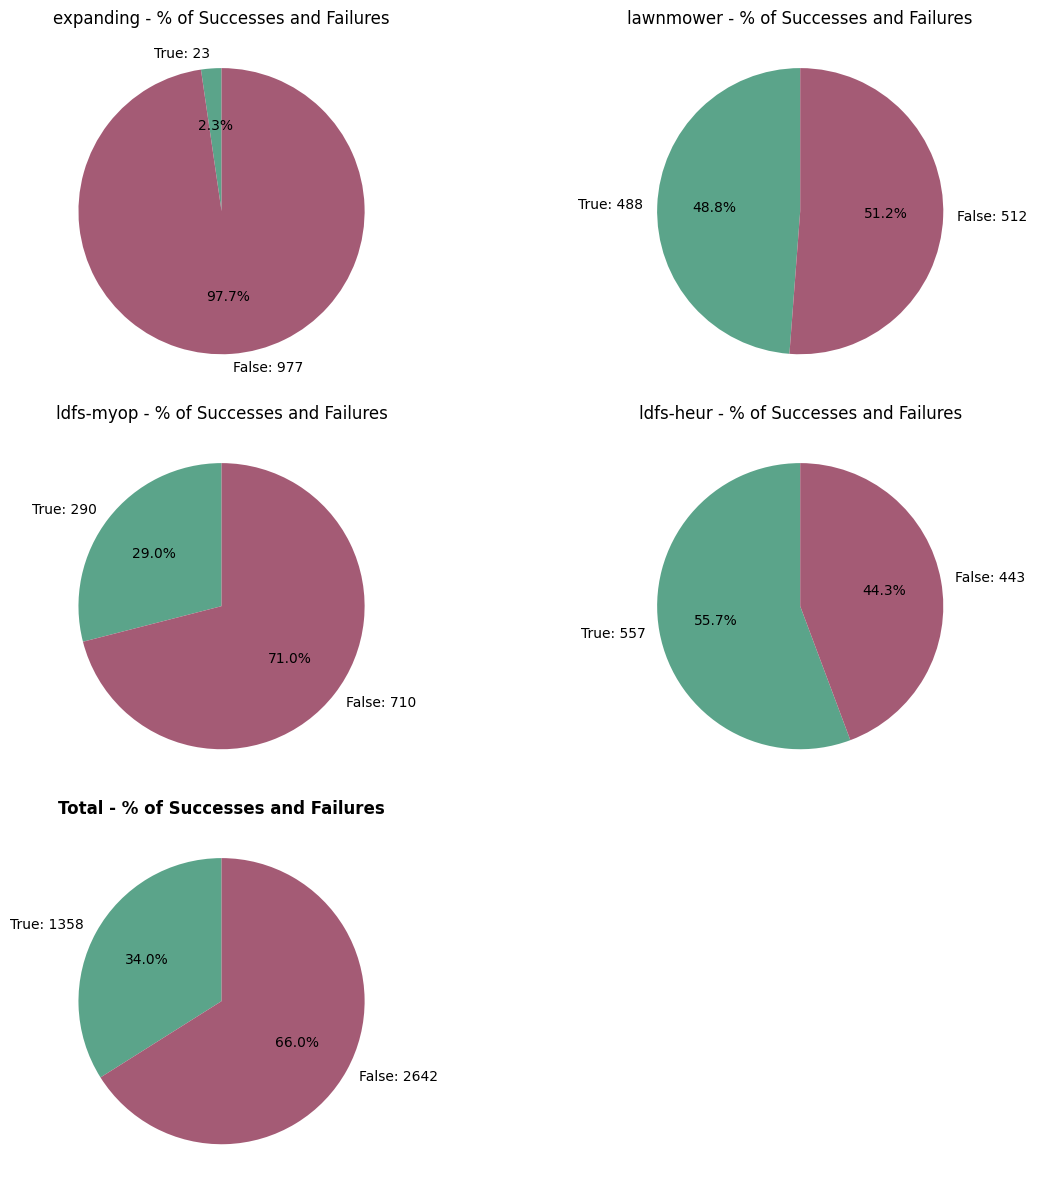

In [46]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp1_3[combined_data_exp1_3["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp1_3["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas-indicios/exp-1-3-grande/pie-exito-1-3-grande.pdf")
plt.show()

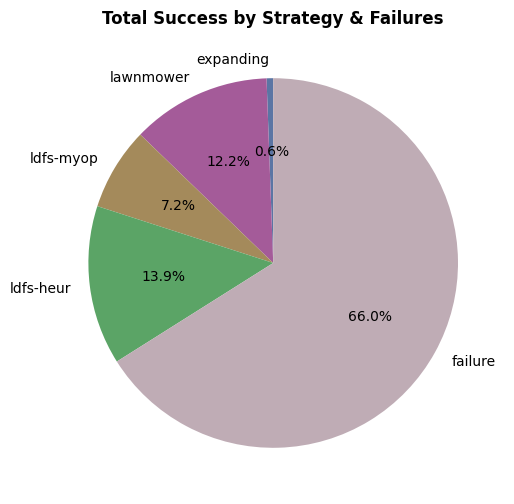

In [47]:
success_counts = combined_data_exp1_3[combined_data_exp1_3["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp1_3["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas-indicios/exp-1-3-grande/pie-exito-total-1-3-grande.pdf")
plt.show()

# Caso de estudio 2 (`fixed`): Escenario 1 (pequeño)
- indicios: 1, posición: fija
- agentes: 1, posición aleatoria desde el borde
- escenario: mediano

**TO DO 🖼️**

## Cargar los archivos

In [48]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "indicios-2-agentes-1-fixed"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp2_1 = process_all(testing_path)

successful_df_exp2_1 = combined_data_exp2_1[combined_data_exp2_1["Found"]]

In [49]:
print(combined_data_exp2_1)

       Strategy  Number of Agents  Steps Steps finder  Distance  Found
0     expanding                 1  176.0        176.0  178.4853   True
1     expanding                 1   19.0         19.0   21.4853   True
2     expanding                 1   95.0         95.0   97.4853   True
3     expanding                 1   94.0         94.0   96.4853   True
4     expanding                 1  180.0        180.0  182.4853   True
...         ...               ...    ...          ...       ...    ...
3995  ldfs-heur                 1  200.0         None  277.4579  False
3996  ldfs-heur                 1  200.0         None  277.4579  False
3997  ldfs-heur                 1  200.0         None  277.4579  False
3998  ldfs-heur                 1  158.0        158.0  218.4752   True
3999  ldfs-heur                 1  200.0         None  277.4579  False

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [50]:
# Descripción general de los datos
combined_data_exp2_1.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,104.548,45.748887,19.0,61.0,98.0,125.0,181.0
lawnmower,1000.0,143.006,58.977524,35.0,87.0,187.5,201.0,201.0
ldfs-heur,1000.0,195.755,11.242926,149.0,200.0,200.0,200.0,200.0
ldfs-myop,1000.0,102.471,84.548055,12.0,16.0,182.0,185.0,197.0


In [51]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp2_1.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,97.0
lawnmower,201.0
ldfs-heur,200.0
ldfs-myop,184.0


In [52]:
combined_data_exp2_1.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000.0,37.0,99.4853,57.0
lawnmower,1000,25,194.6596,465
ldfs-heur,1000,6,277.4579,801
ldfs-myop,1000.0,21.0,223.7351,90.0


#### Histogramas

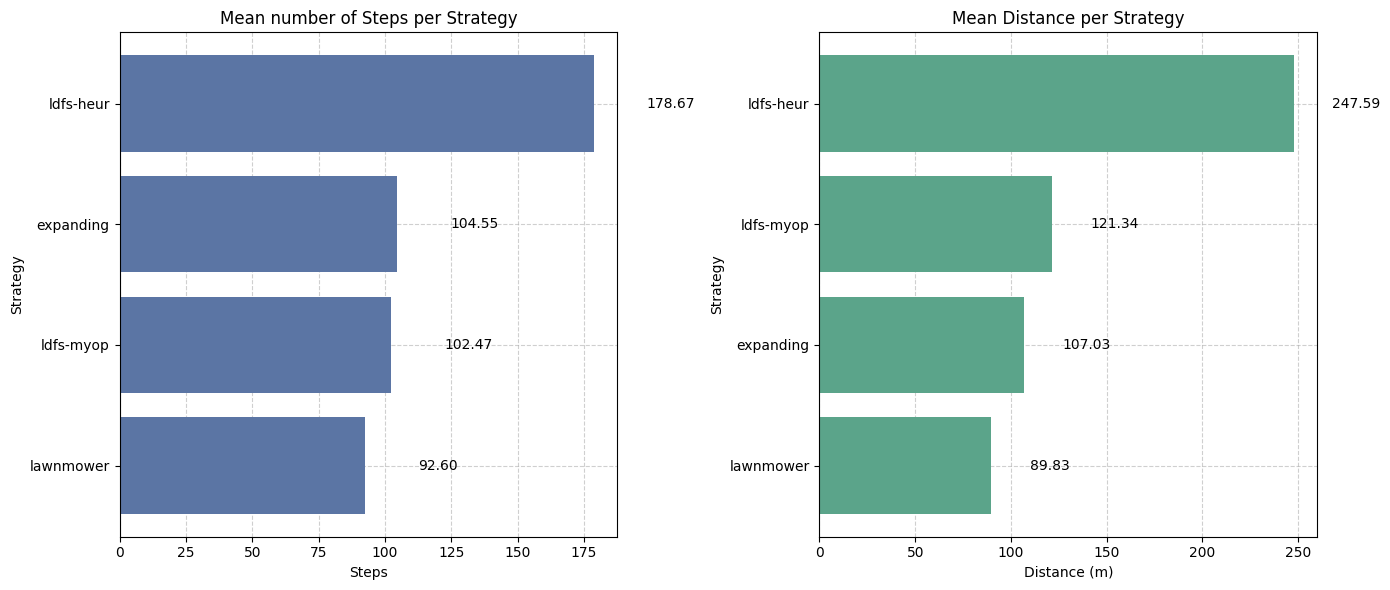

In [53]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp2_1.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp2_1.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
for bar in bars_steps:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas-indicios/exp-2-1-peq-fixed/histo-pasos-2-1-peq-fixed.pdf")
plt.show()


Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [54]:
execution_data = []

for strategy, group in combined_data_exp2_1.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [55]:
global_xmin = combined_data_exp2_1["Steps"].min()
global_xmax = combined_data_exp2_1["Steps"].max()
global_ymax = combined_data_exp2_1.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp2_1[combined_data_exp2_1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)
fig_hist.write_image("graficas-indicios/exp-2-1-peq-fixed/histo-dist-2-1-peq-fixed.pdf")
fig_hist.show()

In [56]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_1[combined_data_exp2_1['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

plt.savefig("graficas-indicios/exp-2-1-peq-fixed/pie-exito-total-2-1-peq-fixed.pdf")
fig_combined.show()

<Figure size 640x480 with 0 Axes>

#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [57]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_1[combined_data_exp2_1['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

plt.savefig("graficas-indicios/exp-2-1-peq-fixed/pie-exito-total-2-1-peq-fixed.pdf")
fig_cumulative.show()

<Figure size 640x480 with 0 Axes>

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [58]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp2_1,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp2_1[combined_data_exp2_1['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas-indicios/exp-2-1-peq-fixed/boxplot-2-1-peq-fixed.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [59]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp2_1.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
print(success_stats)

           num_attempts  successes  success_rate
Strategy                                        
expanding          1000       1000         100.0
lawnmower          1000        535          53.5
ldfs-heur          1000        199          19.9
ldfs-myop          1000       1000         100.0


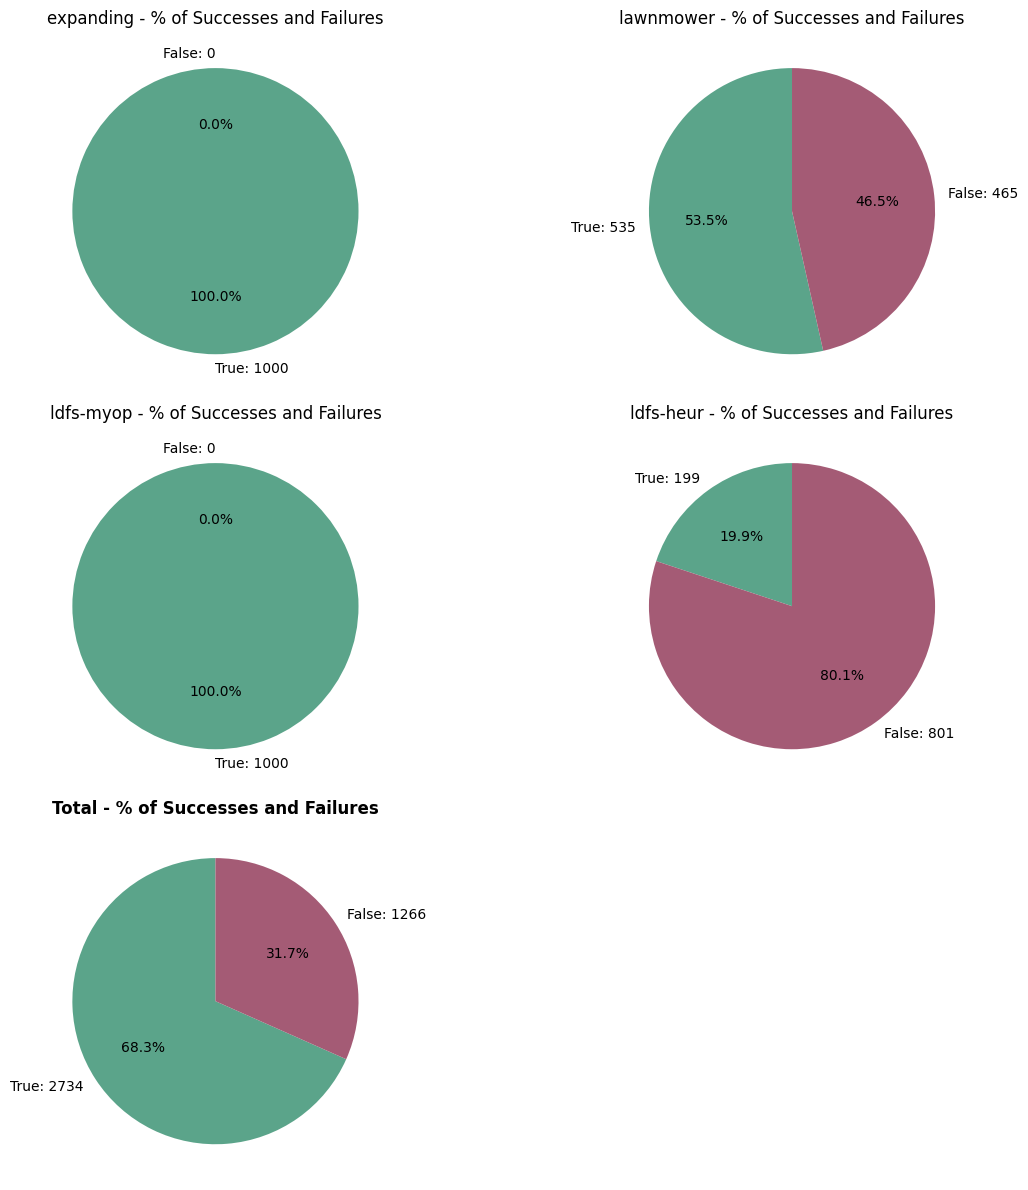

In [60]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp2_1[combined_data_exp2_1["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp2_1["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas-indicios/exp-2-1-peq-fixed/pie-exito-2-1-peq-fixed.pdf")
plt.show()

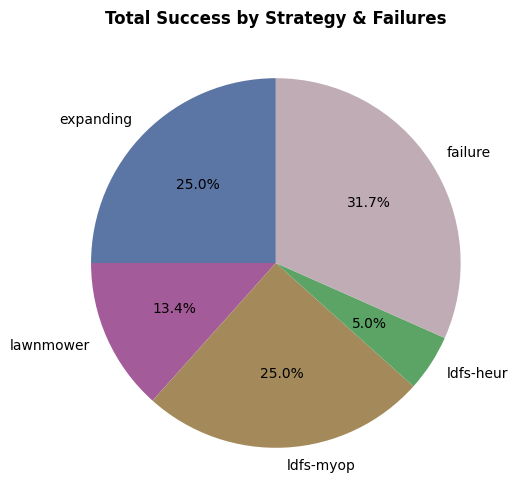

In [61]:
success_counts = combined_data_exp2_1[combined_data_exp2_1["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp2_1["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas-indicios/exp-2-1-peq-fixed/pie-exito-total-2-1-peq-fixed.pdf")
plt.show()

# Caso de estudio 2 (`fixed`): Escenario 2 (mediano)
- indicios: 1, posición fija
- agentes: 1, posición fija
- escenario: mediano

**TO DO 🖼️**

## Cargar los archivos

In [62]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "mediano-indicios-2-agentes-1-fixed"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp2_2 = process_all(testing_path)

successful_df_exp2_2 = combined_data_exp2_2[combined_data_exp2_2["Found"]]

In [63]:
print(combined_data_exp2_2)

       Strategy  Number of Agents  Steps Steps finder  Distance  Found
0     lawnmower                 1  121.0         None   117.105  False
1     lawnmower                 1  121.0         None   117.105  False
2     lawnmower                 1  121.0         None   117.105  False
3     lawnmower                 1  121.0         None   117.105  False
4     lawnmower                 1  121.0         None   117.105  False
...         ...               ...    ...          ...       ...    ...
3995  ldfs-heur                 1  120.0         None  164.7351  False
3996  ldfs-heur                 1  120.0         None  164.7351  False
3997  ldfs-heur                 1  120.0         None  164.7351  False
3998  ldfs-heur                 1  120.0         None  164.7351  False
3999  ldfs-heur                 1  120.0         None  164.7351  False

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [64]:
# Descripción general de los datos
combined_data_exp2_2.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,120.956,0.293513,119.0,121.0,121.0,121.0,121.0
lawnmower,1000.0,121.000,0.000000,121.0,121.0,121.0,121.0,121.0
ldfs-heur,1000.0,120.000,0.000000,120.0,120.0,120.0,120.0,120.0
ldfs-myop,1000.0,119.214,5.256980,49.0,120.0,120.0,120.0,120.0


In [65]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp2_2.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,121.0
lawnmower,121.0
ldfs-heur,120.0
ldfs-myop,120.0


In [66]:
combined_data_exp2_2.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000,2,130.1127,978
lawnmower,1000,1,117.105,1000
ldfs-heur,1000,1,164.7351,1000
ldfs-myop,1000,352,127.2965,11


#### Histogramas

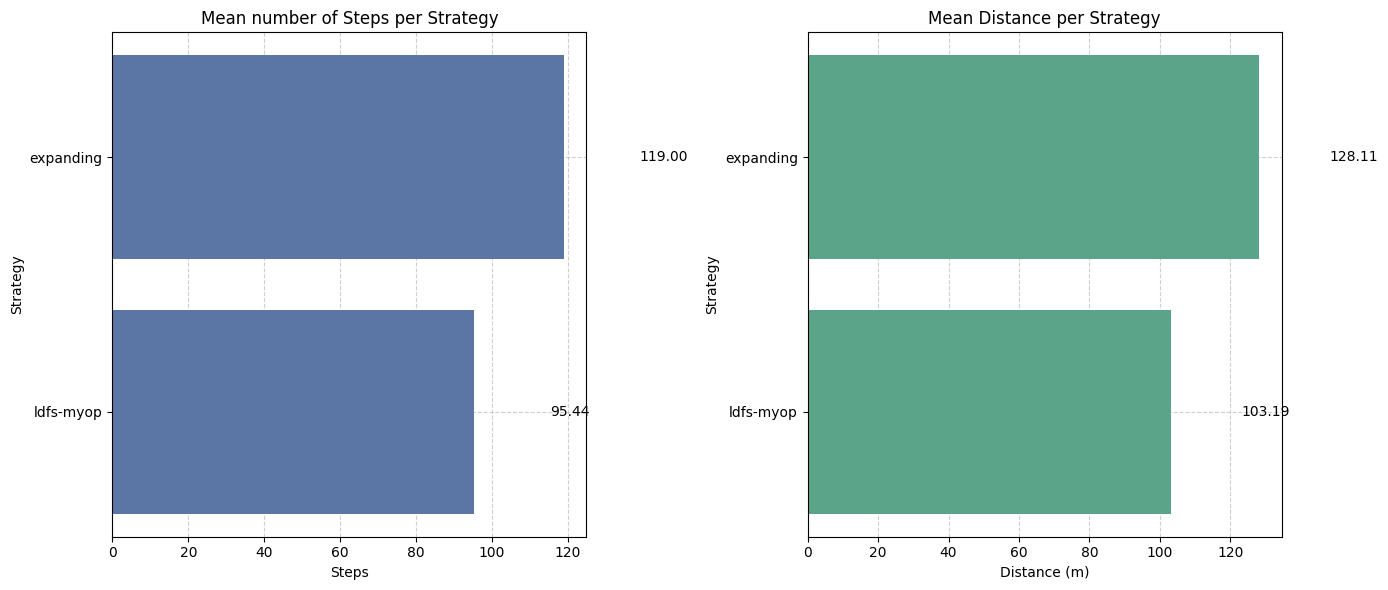

In [67]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp2_2.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp2_2.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
for bar in bars_steps:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas-indicios/exp-2-2-mediano-fixed/histo-pasos-2-2-mediano-fixed.pdf")
plt.show()


Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [68]:
execution_data = []

for strategy, group in combined_data_exp2_2.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [69]:
global_xmin = combined_data_exp2_2["Steps"].min()
global_xmax = combined_data_exp2_2["Steps"].max()
global_ymax = combined_data_exp2_2.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1
    print(row, col)
    print(strategy)

    strategy_data = combined_data_exp2_2[combined_data_exp2_2['Strategy'] == strategy]['Steps'].dropna()
    print(strategy_data)
    print(len(strategy_data), len(strategy_data)>1)
    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data.unique()) > 1:
        print(strategy)
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)
fig_hist.write_image("graficas-indicios/exp-2-2-mediano-fixed/histo-dist-2-2-mediano-fixed.pdf")
fig_hist.show()

1 1
expanding
200     121.0
201     121.0
202     121.0
203     121.0
204     121.0
        ...  
2995    121.0
2996    121.0
2997    121.0
2998    121.0
2999    121.0
Name: Steps, Length: 1000, dtype: float64
1000 True
expanding
1 2
lawnmower
0       121.0
1       121.0
2       121.0
3       121.0
4       121.0
        ...  
2916    121.0
2917    121.0
2918    121.0
2919    121.0
2920    121.0
Name: Steps, Length: 1000, dtype: float64
1000 True
2 1
ldfs-myop
1021    120.0
1022    120.0
1023    107.0
1024    120.0
1025    120.0
        ...  
2816    120.0
2817    120.0
2818    120.0
2819    120.0
2820    120.0
Name: Steps, Length: 1000, dtype: float64
1000 True
ldfs-myop
2 2
ldfs-heur
3000    120.0
3001    120.0
3002    120.0
3003    120.0
3004    120.0
        ...  
3995    120.0
3996    120.0
3997    120.0
3998    120.0
3999    120.0
Name: Steps, Length: 1000, dtype: float64
1000 True


In [70]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_2[combined_data_exp2_2['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas-indicios/exp-2-2-mediano-fixed/histo-dist-comb-2-2-mediano-fixed.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [71]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_2[combined_data_exp2_2['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas-indicios/exp-2-2-mediano-fixed/cdf-2-2-mediano-fixed.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [72]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp2_2,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp2_2[combined_data_exp2_2['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas-indicios/exp-2-2-mediano-fixed/boxplot-2-2-mediano-fixed.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [73]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp2_2.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
print(success_stats)

           num_attempts  successes  success_rate
Strategy                                        
expanding          1000         22           2.2
lawnmower          1000          0           0.0
ldfs-heur          1000          0           0.0
ldfs-myop          1000         32           3.2


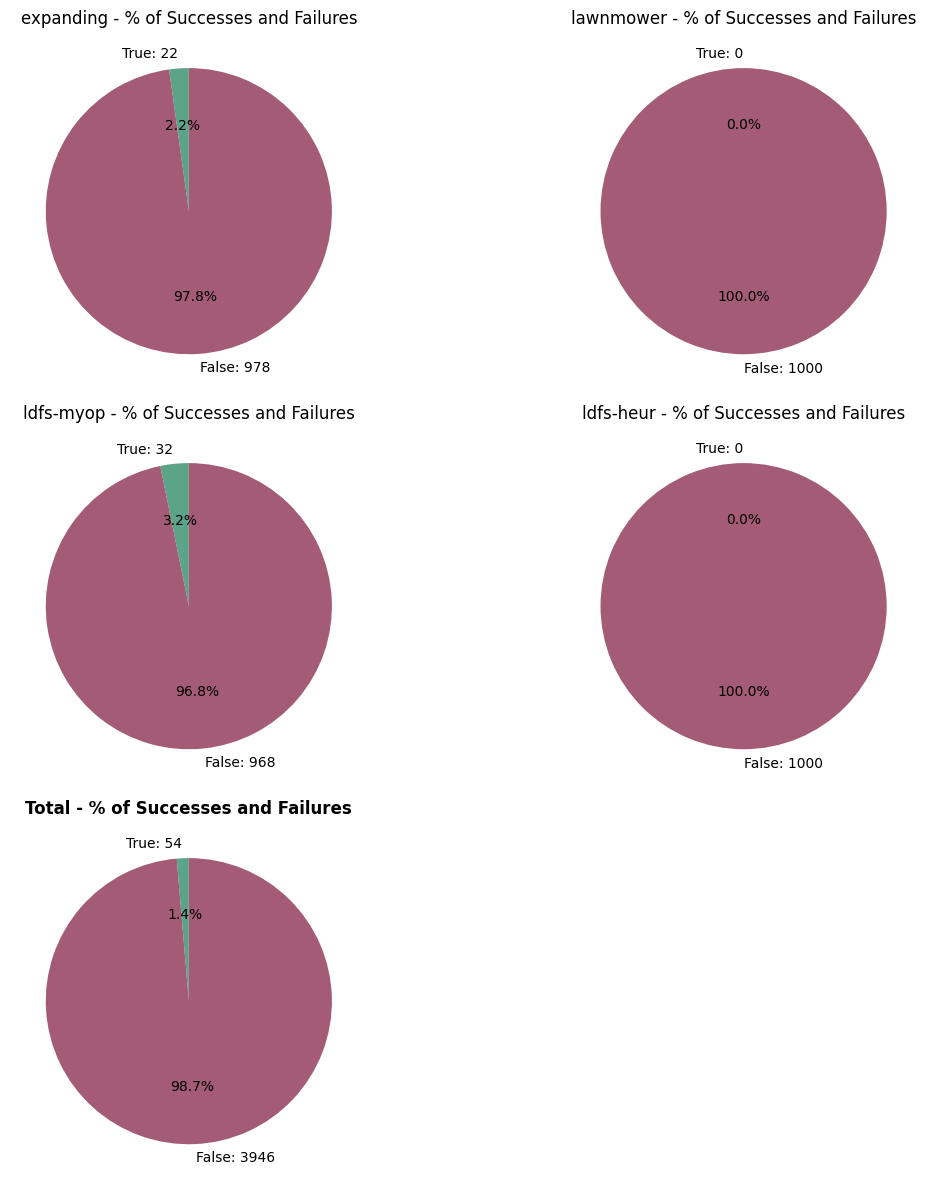

In [74]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp2_2[combined_data_exp2_2["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp2_2["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas-indicios/exp-2-2-mediano-fixed/pie-exito-2-2-mediano-fixed.pdf")
plt.show()

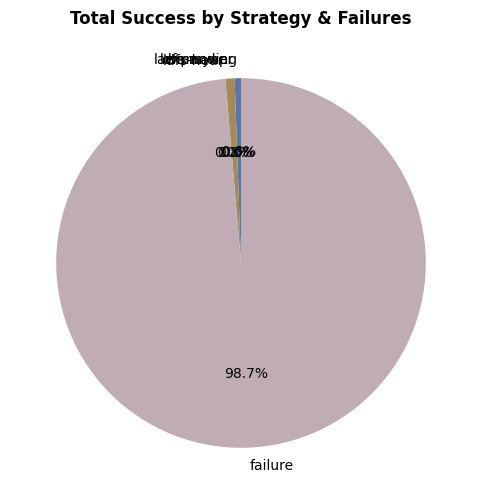

In [75]:
success_counts = combined_data_exp2_2[combined_data_exp2_2["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp2_2["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas-indicios/exp-2-2-mediano-fixed/pie-exito-total-2-2-mediano-fixed.pdf")
plt.show()

# Caso de estudio 2 (`fixed`): Escenario 3
- indicios: 1, posición variable
- agentes: 1, posición fija
- escenario: grande


**TO DO 🖼️**

## Cargar los archivos

In [76]:
# Abrir la carpeta para el analisis (tarda ~1 min/1000 archivos)
conf = "grande-indicios-2-agentes-1-fixed"
testing_path = f"./resultados/{conf}/"

params = json.load(open(f"./pruebas/{conf}.json"))

combined_data_exp2_3 = process_all(testing_path)

successful_df_exp2_3 = combined_data_exp2_3[combined_data_exp2_3["Found"]]

In [77]:
print(combined_data_exp2_3)

       Strategy  Number of Agents   Steps Steps finder   Distance  Found
0     expanding                 1  1201.0         None  1204.7279  False
1     expanding                 1  1201.0         None  1204.7279  False
2     expanding                 1  1201.0         None  1204.7279  False
3     expanding                 1  1201.0         None  1204.7279  False
4     expanding                 1  1201.0         None  1204.7279  False
...         ...               ...     ...          ...        ...    ...
3995  ldfs-heur                 1  1200.0         None  1285.2195  False
3996  ldfs-heur                 1   216.0        216.0   243.0488   True
3997  ldfs-heur                 1  1200.0         None  1275.0479  False
3998  ldfs-heur                 1  1200.0         None   1304.989  False
3999  ldfs-heur                 1   806.0        806.0    866.058   True

[4000 rows x 6 columns]


## Analisis de resultados
Métricas agregadas  
- Tiempo
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Distancia:
  - analisis de distribución
  - estadisticas descriptivas(µ, var...)
  - gráficos (dispersión, histograma, boxplot)

- Tasa de éxito
- Tasa de error
  - estadisticas descriptivas

### Distancia recorrida

In [78]:
# Descripción general de los datos
combined_data_exp2_3.groupby("Strategy")["Steps"].describe()

,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
expanding,1000.0,1190.525,26.918246,1039.0,1201.00,1201.0,1201.0,1201.0
lawnmower,1000.0,1046.283,172.480812,740.0,896.00,1201.0,1201.0,1201.0
ldfs-heur,1000.0,723.336,456.861650,56.0,246.25,777.0,1200.0,1200.0
ldfs-myop,1000.0,1011.740,344.517632,61.0,964.50,1200.0,1200.0,1200.0


In [79]:
# La cantidad de pasos que más se repite (moda)
combined_data_exp2_3.groupby("Strategy")["Steps"].agg(lambda x: x.mode().iloc[0])

,Steps
Strategy,
expanding,1201.0
lawnmower,1201.0
ldfs-heur,1200.0
ldfs-myop,1200.0


In [80]:
combined_data_exp2_3.groupby("Strategy")["Distance"].describe()

,count,unique,top,freq
Strategy,,,,
expanding,1000,9,1204.7279,866
lawnmower,1000,29,1196.287,507
ldfs-heur,1000.0,963.0,87.0833,3.0
ldfs-myop,1000,935,1290.119,4


#### Histogramas

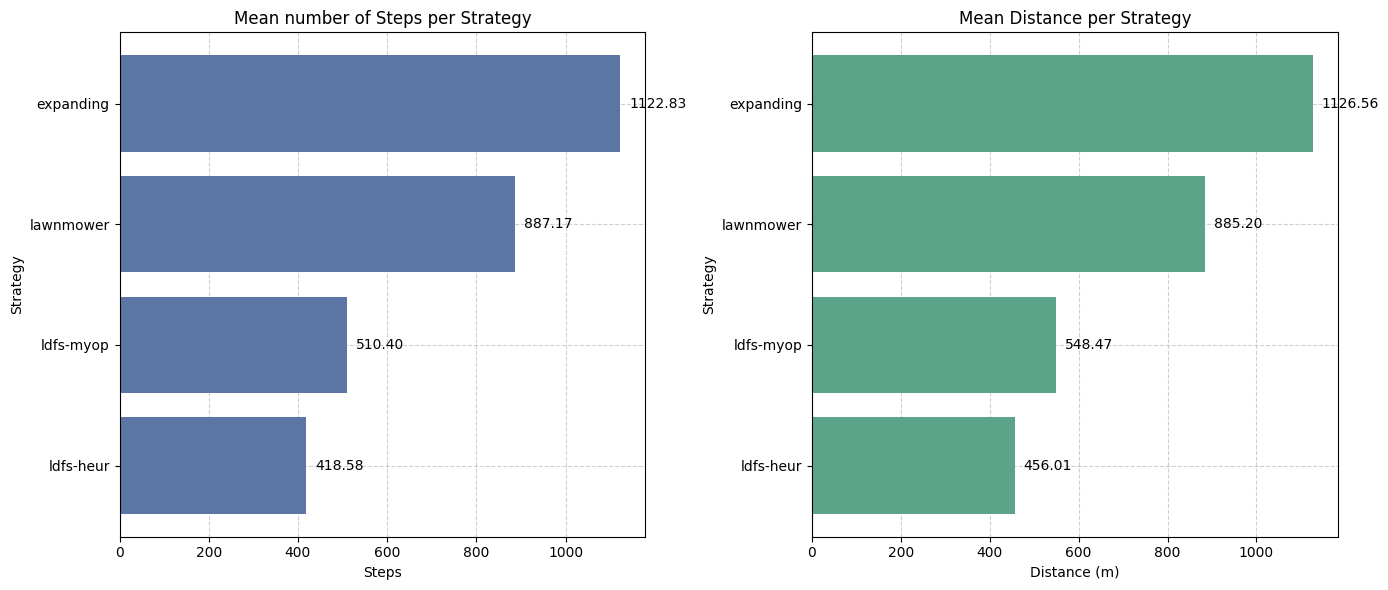

In [81]:
# Histograma
# Se agrupa cada estrategia y se calcula el promedio de los steps y la distancia
mean_steps = successful_df_exp2_3.groupby('Strategy')['Steps'].mean().sort_values()
mean_distance = successful_df_exp2_3.groupby('Strategy')['Distance'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras horizontales para Steps
axes[0].set_axisbelow(True)
axes[0].grid(True, linestyle="--", alpha=0.6)
bars_steps = axes[0].barh(mean_steps.index, mean_steps.values, color='#5B75A4')
axes[0].set_title('Mean number of Steps per Strategy')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Steps
for bar in bars_steps:
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

# Gráfico de barras horizontales para Distance
axes[1].set_axisbelow(True)
axes[1].grid(True, linestyle="--", alpha=0.6)
bars_distance = axes[1].barh(mean_distance.index, mean_distance.values, color='#5BA48A')
axes[1].set_title('Mean Distance per Strategy')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Strategy')

# Se añaden las etiquetas a las barras de Distance
for bar in bars_distance:
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.2f}', va='center', ha='left', color='black')

plt.tight_layout()
plt.savefig("graficas-indicios/exp-2-3-grande-fixed/histo-pasos-2-3-grande-fixed.pdf")
plt.show()


Otra manera de verlo es el número de Steps con respecto al número de ejecuciones.

In [82]:
execution_data = []

for strategy, group in combined_data_exp2_3.groupby("Strategy"):
    num_executions = len(group)
    executions = list(range(1, num_executions + 1))


    execution_data.extend(zip(executions, [strategy] * num_executions))


execution_df = pd.DataFrame(execution_data, columns=["Execution", "Strategy"])

# print(execution_df)

In [83]:
global_xmin = combined_data_exp2_3["Steps"].min()
global_xmax = combined_data_exp2_3["Steps"].max()
global_ymax = combined_data_exp2_3.groupby("Strategy")["Steps"].value_counts().max()


fig_hist = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[f'Distribution of Steps for {s}' for s in strategies],
    vertical_spacing=0.1,
    horizontal_spacing=0.1,
)

for idx, strategy in enumerate(strategies):
    row = idx // 2 + 1
    col = idx % 2 + 1

    strategy_data = combined_data_exp2_3[combined_data_exp2_3['Strategy'] == strategy]['Steps'].dropna()

    # Histograma
    fig_hist.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            marker=dict(color='#5BA48A'),
            opacity=1
        ),
        row=row,
        col=col
    )

    if len(strategy_data) > 1:
        kde = gaussian_kde(strategy_data)
        x_vals = np.linspace(global_xmin, global_xmax, 500)
        y_vals = kde(x_vals)
        y_vals = y_vals * len(strategy_data) * (global_xmax - global_xmin) / 200

        fig_hist.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color='#A45B75', width=1.5),
                name=f'KDE - {strategy}',
            ),
            row=row,
            col=col
        )

    fig_hist.update_xaxes(title_text="Number of Steps", row=row, col=col, range=[global_xmin, global_xmax])
    fig_hist.update_yaxes(title_text="Frequency", row=row, col=col, range=[0, global_ymax])

fig_hist.update_layout(
    showlegend=False,
    title_text="Steps Distribution by Strategy",
    height=1000,
    width=1000,
    bargap=0.1,
)

fig_hist.write_image("graficas-indicios/exp-2-3-grande-fixed/histo-dist-2-3-grande-fixed.pdf")
fig_hist.show()

In [84]:
# Histograma combinado para todas las estrategias
fig_combined = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_3[combined_data_exp2_3['Strategy'] == strategy]['Steps'].dropna()

    # Histograma para cada estrategia
    fig_combined.add_trace(
        go.Histogram(
            x=strategy_data,
            name=strategy,
            nbinsx=200,
            opacity=0.8,
            marker=dict(color=strategy_colors[strategy]),
        )
    )

fig_combined.update_layout(
    title_text="Combined Steps Distribution for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Frequency",
    barmode='overlay',
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_combined.write_image("graficas-indicios/exp-2-3-grande-fixed/histo-dist-comb-2-3-grande-fixed.pdf")
fig_combined.show()


#### Cumulativce Distribution Funcion
La CDF permite visualizar cómo se distribuyen los datos de los 'steps' a medida que se acumulan más valores:

In [85]:
# Figura de Cumulative Distribution Function
fig_cumulative = go.Figure()

for idx, strategy in enumerate(strategies):
    strategy_data = combined_data_exp2_3[combined_data_exp2_3['Strategy'] == strategy]['Steps'].dropna()

    # Calcular la distribución acumulada
    sorted_data = np.sort(strategy_data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Normalización a 0-1
    color = strategy_colors[strategy]  # Color
    line_style = strategy_lines[strategy] # Tipo de línea

    # Curva
    fig_cumulative.add_trace(
        go.Scatter(
            x=sorted_data,
            y=y_vals,
            mode='lines',
            name=strategy,
            line=dict(color=color, dash=line_style),
            opacity=0.8
        )
    )

fig_cumulative.update_layout(
    title_text="Cumulative Distribution of Steps for all strategies",
    xaxis_title="Number of Steps",
    yaxis_title="Cumulative Frequency",
    height=600,
    width=800,
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
    ),
    plot_bgcolor='white',
)

fig_cumulative.write_image("graficas-indicios/exp-2-3-grande-fixed/cdf-2-3-grande-fixed.pdf")
fig_cumulative.show()

#### Boxplot
Por último un para ayudar a entender la distribución con más información (rango, percentiles, outliers, etc.).

In [86]:
point_color = '#BFACB5'


fig_box = px.box(successful_df_exp2_3,
                 x='Strategy',
                 y='Steps',
                 title='Steps Distribution (Box Plot)',
                 labels={'Steps': 'Number of Steps'},
                 height=500,
                 category_orders={'Strategy': strategies},
                 color='Strategy',
                 color_discrete_map=strategy_colors
)

# Añadir los puntos de dispersión para todos los casos de prueba (incluyendo los fallidos)
for strategy in strategies: #combined_data['Strategy'].unique():
    strategy_data = combined_data_exp2_3[combined_data_exp2_3['Strategy'] == strategy]


    fig_box.add_trace(
        go.Scatter(
            x=[strategy] * len(strategy_data),
            y=strategy_data['Steps'],
            mode='markers',
            marker=dict(
                color=point_color,
                opacity=0.2,
                size=5
            ),
            showlegend=False,
        )
    )

fig_box.update_layout(
    height=500,
    title='Steps Distribution (Box Plot with All Attempts)',
    yaxis_title='Number of Steps',
)

fig_box.write_image("graficas-indicios/exp-2-3-grande-fixed/boxplot-2-3-grande-fixed.pdf")
fig_box.show()

### Tiempo para encontrar al objetivo
Muy parecido a la distancia  
Distancia recorrida $\propto$ Tiempo que tarda  
Ya que en cada unidad de tiempo da un paso  

### Tasa de éxito
Separado por estrategia

In [87]:
# success_rate = combined_data.groupby("Strategy")["Found"].mean().map(lambda x: x*100, na_action="ignore").reset_index()
success_stats = combined_data_exp2_3.groupby("Strategy")["Found"].agg([
    ("num_attempts", "count"), # Aunque si fue bien todos deberían tener la misma cantidad (solo para chequear)
    ("successes", "sum"),
    ("success_rate", lambda x: (100 * x.sum() / len(x)))
]).round(2)
print(success_stats)

           num_attempts  successes  success_rate
Strategy                                        
expanding          1000        134          13.4
lawnmower          1000        493          49.3
ldfs-heur          1000        610          61.0
ldfs-myop          1000        273          27.3


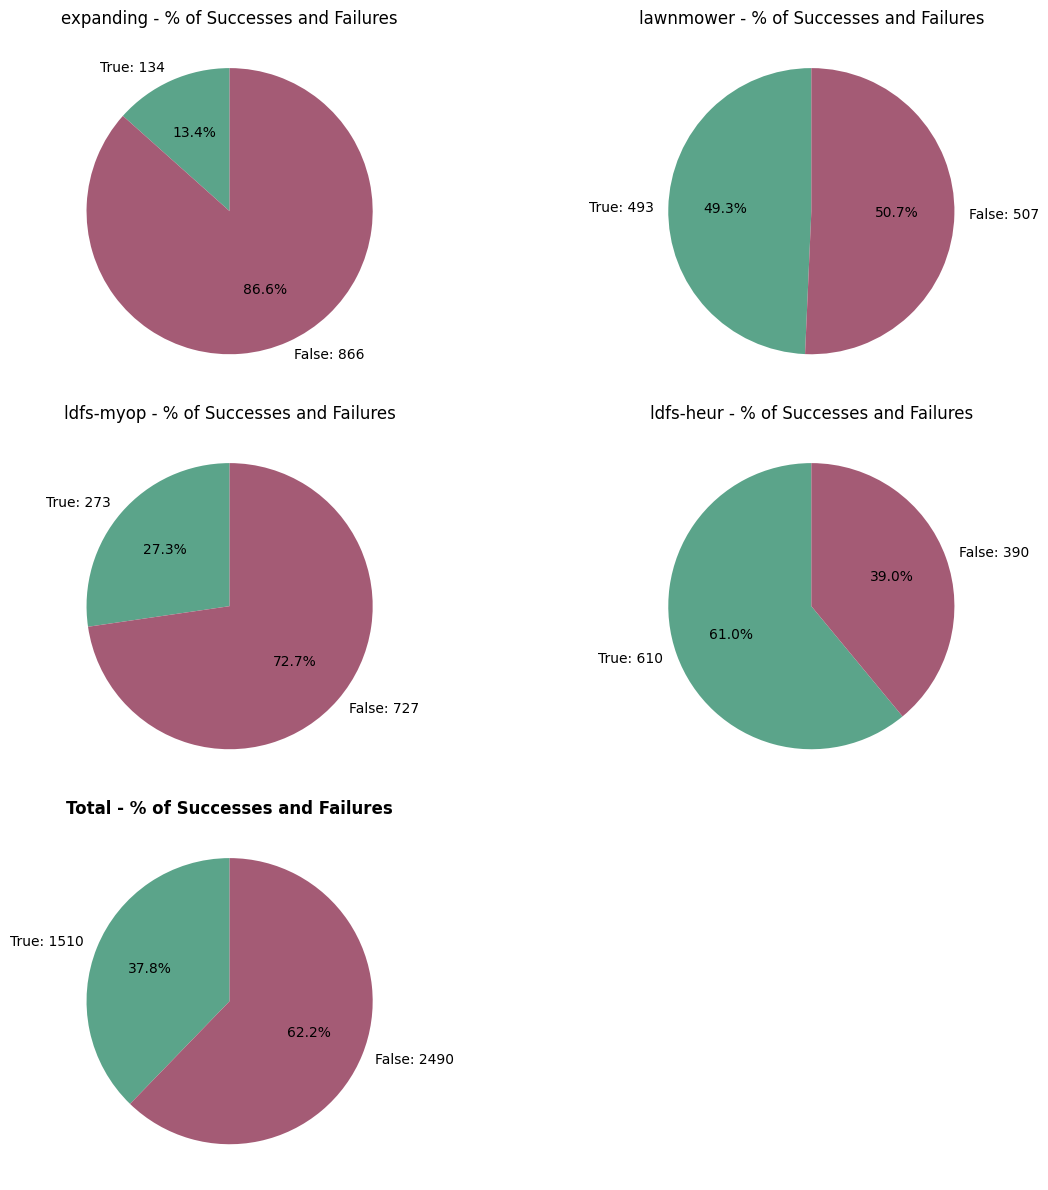

In [88]:
# Gráficas con los porcentajes de misiones que encuentran el objetivo (exito)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, strategy in enumerate(strategies):
    ax = axes[i]

    strategy_data = combined_data_exp2_3[combined_data_exp2_3["Strategy"] == strategy]

    found_counts = strategy_data["Found"].value_counts()
    values = [found_counts.get(True, 0), found_counts.get(False, 0)]
    labels = [f'True: {values[0]}', f'False: {values[1]}']


    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
    ax.set_title(f'{strategy} - % of Successes and Failures')


ax_total = axes[len(strategies)]
found_counts_total = combined_data_exp2_3["Found"].value_counts()
values_total = [found_counts_total.get(True, 0), found_counts_total.get(False, 0)]
labels_total = [f'True: {values_total[0]}', f'False: {values_total[1]}']

ax_total.pie(values_total, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_found.values())
ax_total.set_title('Total - % of Successes and Failures', fontweight='bold')

# Sobra el 6 gráfico de la malla
for j in range(len(strategies) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("graficas-indicios/exp-2-3-grande-fixed/pie-exito-2-3-grande-fixed.pdf")
plt.show()

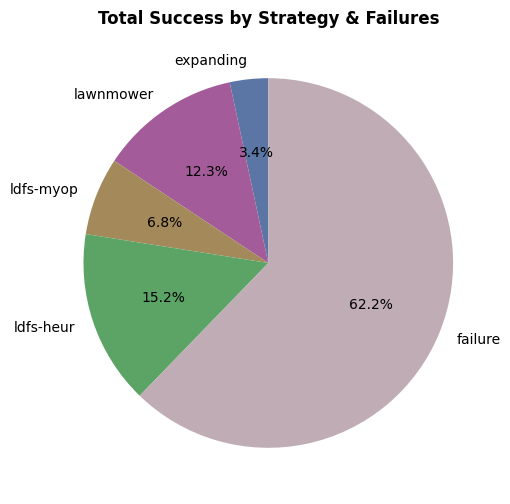

In [89]:
success_counts = combined_data_exp2_3[combined_data_exp2_3["Found"] == True]["Strategy"].value_counts()

failure_count = (combined_data_exp2_3["Found"] == False).sum()

labels = list(strategy_colors.keys())
sizes = [success_counts.get(strategy, 0) for strategy in strategies] + [failure_count]
colors = list(strategy_colors.values())

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
ax.set_title("Total Success by Strategy & Failures", fontweight="bold")

plt.savefig("graficas-indicios/exp-2-3-grande-fixed/pie-exito-total-2-3-grande-fixed.pdf")
plt.show()

# Limpiar entorno

In [90]:
drive.flush_and_unmount()